# 07b Feature Space Design

This notebook defines the feature spaces that will be used for the recommendation experiments.

The previous notebooks cleaned the data, explored the datasets, and identified important limitations regarding dataset linkage and lyrics availability.

Before building recommendation models, we need to decide which feature combinations are realistic and useful.

## 1. Notebook Goal

The goal of this notebook is to compare possible feature spaces for the content-based recommender system.

Instead of immediately using all available data, we first check which feature sources can actually be used together.

This is important because different datasets cover different subsets of tracks.

The notebook focuses on three main questions:

- Which feature sources are available for most tracks?
- Which feature combinations are realistic for modelling?
- Which feature spaces should be tested in the next notebook?

In [6]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data" / "processed"

tracks = pd.read_parquet(processed_dir / "tracks_clean.parquet")
artists = pd.read_parquet(processed_dir / "artists_clean.parquet")
albums = pd.read_parquet(processed_dir / "albums_clean.parquet")
audio_features = pd.read_parquet(processed_dir / "audio_features_clean.parquet")
lyrics_features = pd.read_parquet(processed_dir / "lyrics_features_valid_clean.parquet")

print(f"Tracks: {len(tracks):,}")
print(f"Artists: {len(artists):,}")
print(f"Albums: {len(albums):,}")
print(f"Audio Features: {len(audio_features):,}")
print(f"Lyrics Features: {len(lyrics_features):,}")

Tracks: 95,977
Artists: 56,129
Albums: 75,511
Audio Features: 95,948
Lyrics Features: 74,128


In [9]:
dataset_shapes = pd.DataFrame({
    "Dataset": [
        "Tracks",
        "Artists",
        "Albums",
        "Audio Features",
        "Lyrics Features"
    ],
    "Rows": [
        len(tracks),
        len(artists),
        len(albums),
        len(audio_features),
        len(lyrics_features)
    ],
    "Columns": [
        tracks.shape[1],
        artists.shape[1],
        albums.shape[1],
        audio_features.shape[1],
        lyrics_features.shape[1]
    ]
})

dataset_shapes

,Dataset,Rows,Columns
0,Tracks,95977,30
1,Artists,56129,8
2,Albums,75511,14
3,Audio Features,95948,208
4,Lyrics Features,74128,7


The cleaned datasets have already been exported as parquet files in the previous notebooks.

These datasets form the basis for defining the possible feature spaces.

The number of rows differs because not every track is linked to artist, album, audio, or lyrics information.

# 2. Dataset Linkage Analysis

Before defining feature spaces, it is important to understand how many tracks can actually be linked to each data source.

The cleaned datasets originate from different Spotify endpoints and external sources. As a result, not every track contains artist metadata, album information, audio features, and lyrics features simultaneously.

The following analysis summarizes the availability of each source relative to the cleaned track dataset.

In [10]:
linkage = pd.DataFrame({
    "Dataset": [
        "Artists",
        "Albums",
        "Audio Features",
        "Lyrics Features"
    ],
    "Tracks Linked (%)": [
        tracks["id"].isin(artists["track_id"]).mean() * 100,
        tracks["id"].isin(albums["track_id"]).mean() * 100,
        tracks["id"].isin(audio_features["track_id"]).mean() * 100,
        tracks["id"].isin(lyrics_features["track_id"]).mean() * 100
    ]
})

linkage = linkage.sort_values(
    "Tracks Linked (%)",
    ascending=False
)

linkage

,Dataset,Tracks Linked (%)
2,Audio Features,99.969784
1,Albums,77.831147
3,Lyrics Features,77.235171
0,Artists,46.174604


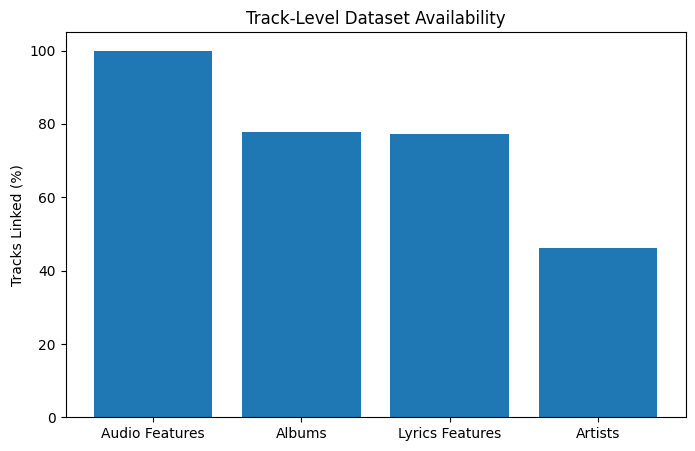

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    linkage["Dataset"],
    linkage["Tracks Linked (%)"]
)

plt.ylabel("Tracks Linked (%)")
plt.title("Track-Level Dataset Availability")

plt.ylim(0, 105)

plt.show()

In [12]:
all_sources = (
    tracks["id"].isin(artists["track_id"])
    &
    tracks["id"].isin(albums["track_id"])
    &
    tracks["id"].isin(audio_features["track_id"])
    &
    tracks["id"].isin(lyrics_features["track_id"])
)

print(
    f"Tracks with all sources available: "
    f"{all_sources.mean()*100:.2f}%"
)

Tracks with all sources available: 32.20%


### Key Observation

Audio features are available for almost all tracks and therefore provide the strongest foundation for recommendation models.

Lyrics and album information are available for a substantial portion of the dataset, while artist metadata is available for fewer than half of all tracks.

Only a subset of tracks can be linked to every available source simultaneously. This creates a trade-off between feature richness and dataset size that must be considered when designing recommendation models.

# 3. Lyrics Audit Summary

During feature engineering, an additional audit of the lyrics data was performed.

Initially, the lyrics column appeared complete because no missing values were present. However, further inspection revealed that a portion of tracks contained placeholder values rather than actual song lyrics.

Examples included:

- "-99"
- "Instrumental"
- "Lyrics not released"
- Empty lyric entries

As a result, the effective coverage of usable lyrics is lower than the apparent coverage of the raw lyrics column.

In [13]:
placeholder_mask = (
    tracks["lyrics"].eq("-99")
    |
    tracks["lyrics"].str.contains(
        "Lyrics not released",
        case=False,
        na=False
    )
    |
    tracks["lyrics"].str.contains(
        "Instrumental",
        case=False,
        na=False
    )
    |
    (tracks["lyrics"].str.strip() == "")
)

lyrics_audit = pd.DataFrame({
    "Metric": [
        "Total Tracks",
        "Tracks with Valid Lyrics",
        "Tracks with Placeholder Lyrics",
        "Valid Lyrics (%)",
        "Placeholder Lyrics (%)"
    ],
    "Value": [
        len(tracks),
        (~placeholder_mask).sum(),
        placeholder_mask.sum(),
        round((~placeholder_mask).mean() * 100, 2),
        round(placeholder_mask.mean() * 100, 2)
    ]
})

lyrics_audit

,Metric,Value
0,Total Tracks,95977.00
1,Tracks with Valid Lyrics,80253.00
2,Tracks with Placeholder Lyrics,15724.00
3,Valid Lyrics (%),83.62
4,Placeholder Lyrics (%),16.38


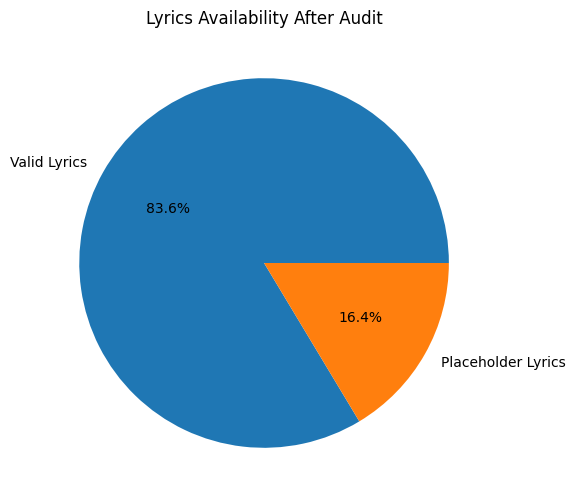

In [14]:
plt.figure(figsize=(6,6))

plt.pie(
    [
        (~placeholder_mask).sum(),
        placeholder_mask.sum()
    ],
    labels=[
        "Valid Lyrics",
        "Placeholder Lyrics"
    ],
    autopct="%1.1f%%"
)

plt.title("Lyrics Availability After Audit")

plt.show()

In [15]:
valid_lyrics_tracks = (~placeholder_mask).sum()

print(
    f"Tracks with usable lyrics: "
    f"{valid_lyrics_tracks:,}"
)

Tracks with usable lyrics: 80,253


### Key Observation

Although the lyrics column contains values for nearly every track, approximately 16.4% of entries consist of placeholders or non-lyrical content.

After removing these entries, the remaining lyrics corpus still contains a large number of tracks and represents a potentially valuable source of semantic information for recommendation models.

# 4. Candidate Feature Spaces

Based on the previous analyses, several possible feature spaces can be constructed for recommendation experiments.

Rather than immediately selecting a single approach, multiple candidate feature spaces will be evaluated and compared.

Each feature space balances three factors:

- Dataset coverage
- Feature richness
- Computational complexity

## Model A – Audio-Based Representation

This feature space uses:

- Spotify audio features
- Extracted low-level audio features

Advantages:

- Highest dataset coverage
- Large number of audio descriptors
- Computationally efficient

Limitations:

- No lyrical information
- Recommendations are based purely on musical characteristics

## Model B – Audio + Engineered Lyrics

This feature space combines:

- Spotify audio features
- Extracted low-level audio features
- Lyrics-derived metrics

Examples:

- Vocabulary wealth
- Number of words
- Number of sentences
- Sentence similarity

Advantages:

- Adds linguistic information
- Relatively compact feature set

Limitations:

- Lower dataset coverage
- Lyrics represented only through summary statistics

## Model C – Audio + Lyrics Text

This feature space combines:

- Spotify audio features
- Extracted low-level audio features
- Full song lyrics

The lyrics will later be transformed using text vectorization methods such as TF-IDF.

Advantages:

- Captures semantic content of songs
- Highest lyrics coverage
- Potentially richer recommendations

Limitations:

- Higher dimensionality
- Increased computational cost

In [18]:
feature_spaces = pd.DataFrame({
    "Model": [
        "A",
        "B",
        "C"
    ],
    "Feature Space": [
        "Audio Features",
        "Audio + Engineered Lyrics",
        "Audio + Full Lyrics"
    ],
    "Approx. Coverage (%)": [
        99.97,
        77.24,
        83.62
    ]
})

feature_spaces

,Model,Feature Space,Approx. Coverage (%)
0,A,Audio Features,99.97
1,B,Audio + Engineered Lyrics,77.24
2,C,Audio + Full Lyrics,83.62


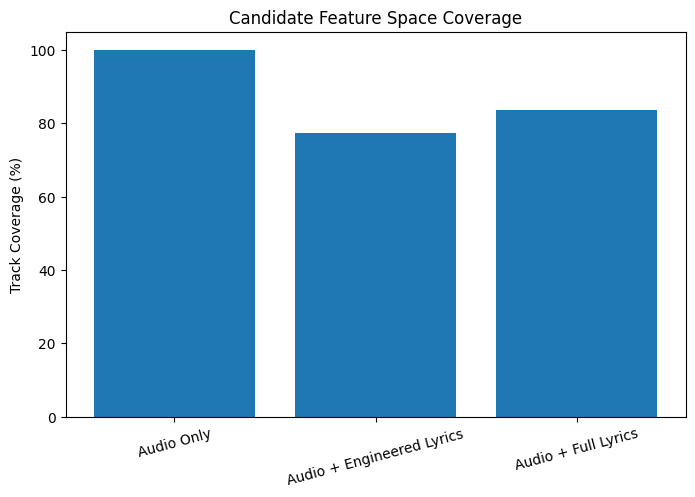

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_spaces["Feature Space"],
    feature_spaces["Approx. Coverage (%)"]
)

plt.ylabel("Track Coverage (%)")
plt.title("Candidate Feature Space Coverage")

plt.ylim(0,105)

plt.xticks(rotation=15)

plt.show()

### Key Observation

The three candidate feature spaces represent different trade-offs.

Model A maximizes coverage and simplicity.

Model B incorporates engineered linguistic information but reduces the available dataset.

Model C retains a larger portion of the dataset while introducing semantic information from song lyrics.

The recommendation experiments in the next notebook will compare these approaches and evaluate their impact on recommendation quality.

# 5. Planned Experiments

The next phase of the project focuses on building and comparing recommendation models based on the candidate feature spaces.

The experiments will investigate whether additional linguistic information improves recommendation quality compared to audio-based recommendations alone.

Three recommendation approaches will be evaluated:

- Model A: Audio Features
- Model B: Audio Features + Engineered Lyrics
- Model C: Audio Features + Full Lyrics

Recommendations will be generated using similarity-based approaches and compared qualitatively.

## Evaluation Strategy

The recommendation models will be compared using:

- Recommendation consistency
- Genre coherence
- Diversity of recommended tracks
- Qualitative inspection of recommendation results

The objective is not only to generate similar songs, but also to understand how different feature representations influence recommendation behaviour.

## Expected Outcome

This notebook identified three viable feature spaces for recommendation experiments.

The next notebook will implement similarity-based recommendation models and compare their behaviour across the different feature spaces.

The results will provide insight into whether audio characteristics alone are sufficient or whether lyrics-based information contributes additional value.